In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay

In [2]:
diabetes_data = pd.read_csv('/Users/maheshg/Dropbox/Sample Datasets Kaggle/diabetes 2.csv')

In [3]:
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,7,127.978658,74.434931,30.795284,57.937568,29.524220,0.458167,41,1
1,9,100.178783,60.909403,26.770289,112.454493,34.355269,0.365299,30,1
2,1,90.264591,61.673580,31.801643,96.688063,26.567985,0.427536,37,1
3,1,161.083229,92.460974,33.223057,190.645597,28.910178,0.721804,64,0
4,4,139.601992,64.428156,39.060670,63.480335,28.796877,0.403001,35,0


In [4]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,964.000000,964.000000,964.000000,964.000000,964.000000,964.000000,964.000000,964.000000,964.00000
mean,6.858921,121.264163,70.600467,25.106220,81.767095,29.886359,0.522150,43.303942,0.50000
std,4.344081,31.493230,12.070403,7.784677,38.162614,5.874254,0.277563,14.806889,0.50026
min,0.000000,50.000000,40.000000,10.000000,15.000000,15.000000,0.100000,18.000000,0.00000
25%,3.000000,101.166108,62.285977,19.691100,55.329655,25.826711,0.307019,31.000000,0.00000
50%,7.000000,121.908765,70.960602,24.998921,80.048890,30.117524,0.511531,43.000000,0.50000
75%,11.000000,142.864532,78.842939,30.352099,108.238207,33.908275,0.717463,56.000000,1.00000
max,14.000000,200.000000,100.000000,50.000000,226.308072,47.045318,1.579840,69.000000,1.00000


In [5]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               964 non-null    int64  
 1   Glucose                   964 non-null    float64
 2   BloodPressure             964 non-null    float64
 3   SkinThickness             964 non-null    float64
 4   Insulin                   964 non-null    float64
 5   BMI                       964 non-null    float64
 6   DiabetesPedigreeFunction  964 non-null    float64
 7   Age                       964 non-null    int64  
 8   Outcome                   964 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 67.9 KB


In [6]:
diabetes_data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
diabetes_data.value_counts

<bound method DataFrame.value_counts of      Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0              7  127.978658      74.434931      30.795284   57.937568   
1              9  100.178783      60.909403      26.770289  112.454493   
2              1   90.264591      61.673580      31.801643   96.688063   
3              1  161.083229      92.460974      33.223057  190.645597   
4              4  139.601992      64.428156      39.060670   63.480335   
..           ...         ...            ...            ...         ...   
959            8   96.091457      67.656428      23.714100   99.117755   
960            2  142.262538      77.539683      37.724027  104.435907   
961            1  113.249823      69.241319      24.107181  116.358393   
962           13  112.940438      72.809651      10.000000   49.872635   
963            9  161.533263      70.940184      19.355154   87.322409   

           BMI  DiabetesPedigreeFunction  Age  Outcome  
0    29.524220

In [8]:
diabetes_data.shape

(964, 9)

In [9]:
X = diabetes_data.drop('Outcome', axis=1)
y = diabetes_data['Outcome']

Train a simple model: 

In [10]:
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

RandomForestRegressor(random_state=42)

In [11]:
featues = diabetes_data[["BMI","Glucose"]]

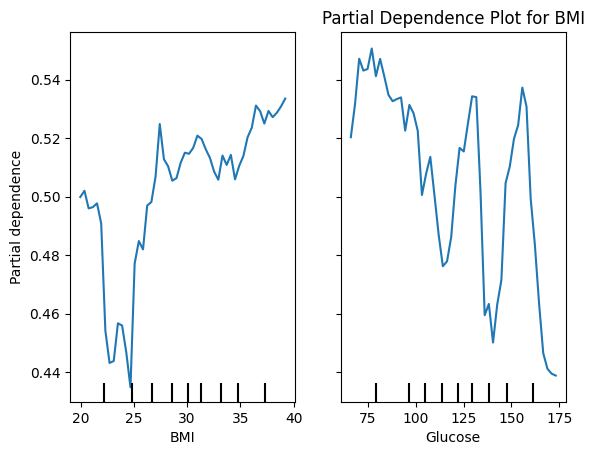

In [12]:
#Partial Dependence Plot for BMI:
PartialDependenceDisplay.from_estimator(model,X, featues, 
                                        kind="average",
                                        grid_resolution=50)
plt.title("Partial Dependence Plot for BMI")
plt.show()

Post HOC - Permutation Feature Importance 

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score,accuracy_score

In [14]:
X = diabetes_data.drop('Outcome', axis=1)
y = diabetes_data['Outcome']

In [15]:
### Train / Test Split: 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
### Fit a Random Forest Model 
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
### Baseline Accuracy:
print("Baseline Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Baseline Accuracy: 0.48704663212435234


In [18]:
### Permutation Importance 
importance_diabetes = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

In [19]:
print(importance_diabetes)

{'importances_mean': array([ 0.01398964, -0.00362694, -0.03626943,  0.02746114, -0.02435233,
        0.02124352, -0.00777202, -0.03626943]), 'importances_std': array([0.01911489, 0.01410431, 0.01622018, 0.02329302, 0.01671737,
       0.02191532, 0.01969594, 0.02419195]), 'importances': array([[ 0.02072539,  0.02072539,  0.00518135,  0.00518135,  0.05181347,
        -0.01036269, -0.01554404,  0.02590674,  0.00518135,  0.03108808],
       [-0.01554404, -0.01554404,  0.00518135,  0.00518135, -0.01554404,
         0.        ,  0.01554404,  0.02072539, -0.02072539, -0.01554404],
       [-0.02072539, -0.01036269, -0.05699482, -0.06217617, -0.02590674,
        -0.03108808, -0.03108808, -0.04663212, -0.02590674, -0.05181347],
       [ 0.        ,  0.06735751,  0.02072539,  0.03626943, -0.01554404,
         0.02590674,  0.04663212,  0.05181347,  0.01554404,  0.02590674],
       [-0.01554404, -0.05699482, -0.03626943, -0.00518135, -0.02590674,
        -0.00518135, -0.01554404, -0.02590674, -0.04

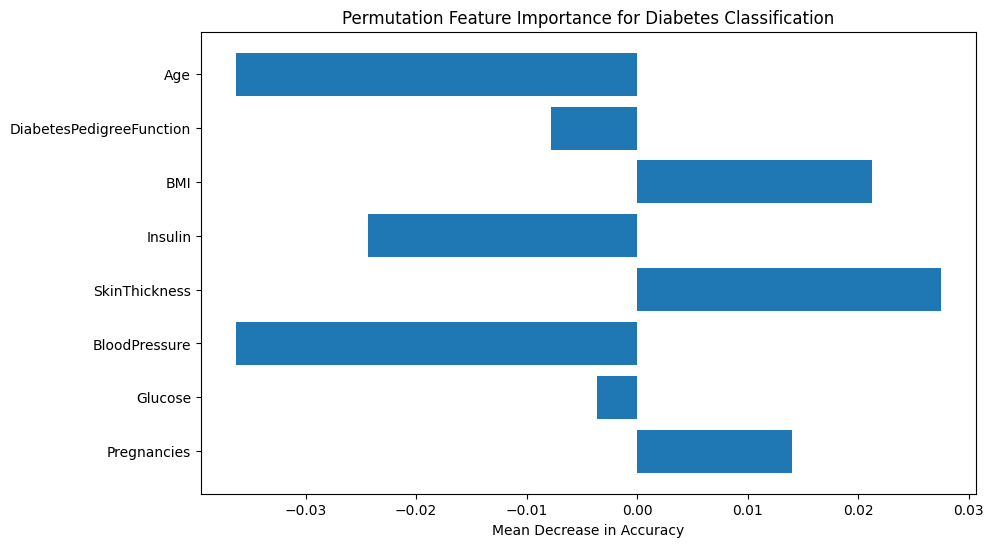

In [20]:
plt.figure(figsize=(10,6))
plt.barh(X.columns, importance_diabetes.importances_mean)
plt.xlabel("Mean Decrease in Accuracy")
plt.title("Permutation Feature Importance for Diabetes Classification")
plt.show()

In [21]:
import pandas as pd
import shap 
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

In [22]:
X = diabetes_data.drop('Outcome', axis=1)
y = diabetes_data['Outcome']

In [23]:
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

RandomForestClassifier(random_state=42)

In [24]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

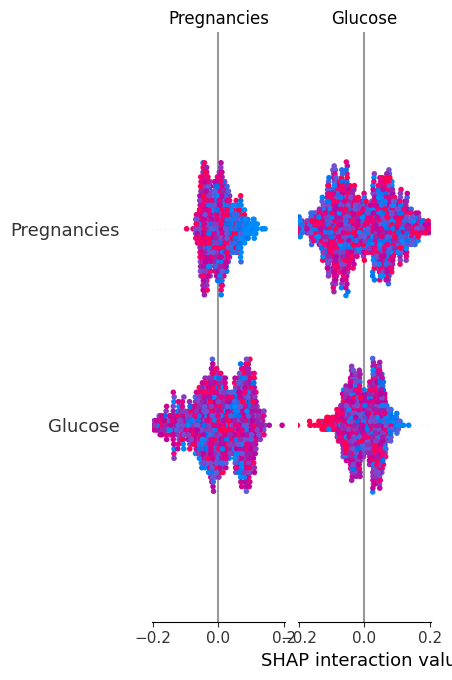

In [25]:
shap.summary_plot(shap_values, X, plot_type="bar")

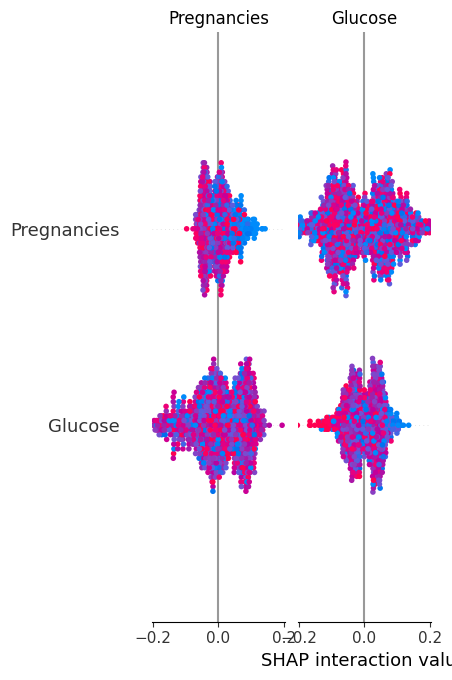

In [26]:
shap.initjs()
shap.summary_plot(shap_values, X)